### **Pràctica 3:Estructura electronica de molècules amb SIESTA C60**

El primer que farem serà instalar la llibreria sisl, nodify i plotly

In [1]:
!pip install sisl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 42.6 MB/s eta 0:00:00


In [2]:
!pip install nodify
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 21.9 MB/s eta 0:00:00


Ara importem totes les llibreries necessaries

In [3]:
from sisl import *
import numpy as np
import matplotlib.pyplot as plt

També importem tots els fitxers de dades

In [4]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving 0_NORMAL_EXIT to 0_NORMAL_EXIT (1)
Saving BASIS_ENTHALPY to BASIS_ENTHALPY (1)
Saving BASIS_HARRIS_ENTHALPY to BASIS_HARRIS_ENTHALPY (1)
Saving C.ion to C (1).ion
Saving C.ion.nc to C.ion (1).nc
Saving C.ion.xml to C.ion (1).xml
Saving C.psf to C (1).psf
Saving C60.alloc to C60 (1).alloc
Saving C60.BASIS_ENTHALPY to C60 (1).BASIS_ENTHALPY
Saving C60.bib to C60 (1).bib
Saving C60.BONDS to C60 (1).BONDS
Saving C60.BONDS_FINAL to C60 (1).BONDS_FINAL
Saving C60.DM to C60 (1).DM
Saving C60.EIG to C60 (1).EIG
Saving C60.FA to C60 (1).FA
Saving C60.HSX to C60 (1).HSX
Saving C60.KP to C60 (1).KP
Saving C60.ORB_INDX to C60 (1).ORB_INDX
Saving C60.STRUCT_OUT to C60 (1).STRUCT_OUT
Saving C60.XV to C60 (1).XV
Saving C60.xyz to C60 (1).xyz
Saving C60_coords.fdf to C60_coords (1).fdf
Saving CLOCK to CLOCK (1)
Saving fdf.20260312T140806.991.log to fdf.20260312T140806.991 (1).log
Saving FORCE_STRESS to FORCE_STRESS (1)
Saving MESSAGES to MESSAGES (1)
Saving OUTVARS.yml to OUTVARS (1).yml
Saving

In [7]:
system = Geometry.read("C60_coords.fdf")

Càrreguem i visualitzem un fitxer fdf amb coordenades

In [8]:
system.plot()

In [9]:
system.plot(axes="xy")

Ara buscarem llegir el Hamiltonià amb tota la informació del sistema corresponent a aquest Hamiltonià.

In [10]:
fdf = get_sile("RUN.fdf")

In [11]:
H = fdf.read_hamiltonian()
print(H)

Hamiltonian{non-zero: 418830, orthogonal: False,
 Spin{unpolarized},
 Geometry{na: 60, no: 780,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01100, maxR: 3.30951,
    AtomicOrbital{2sZ1, q0: 2.0, SphericalOrbital{l: 0, R: 2.6548991702136426, q0: 2.0}},
    AtomicOrbital{2sZ2, q0: 0.0, SphericalOrbital{l: 0, R: 1.6858398488357096, q0: 0.0}},
    AtomicOrbital{2pyZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260037558, q0: 2.0}},
    AtomicOrbital{2pzZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260037558, q0: 2.0}},
    AtomicOrbital{2pxZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260037558, q0: 2.0}},
    AtomicOrbital{2pyZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003304, q0: 0.0}},
    AtomicOrbital{2pzZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003304, q0: 0.0}},
    AtomicOrbital{2pxZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003304, q0: 0.0}},
    AtomicOrbital{3dxyZ1P, q0: 0.0, SphericalOrbital{l: 2, R: 3.309

Dibuixem els orbitals atòmics i els guardem  com a fitxers .cube

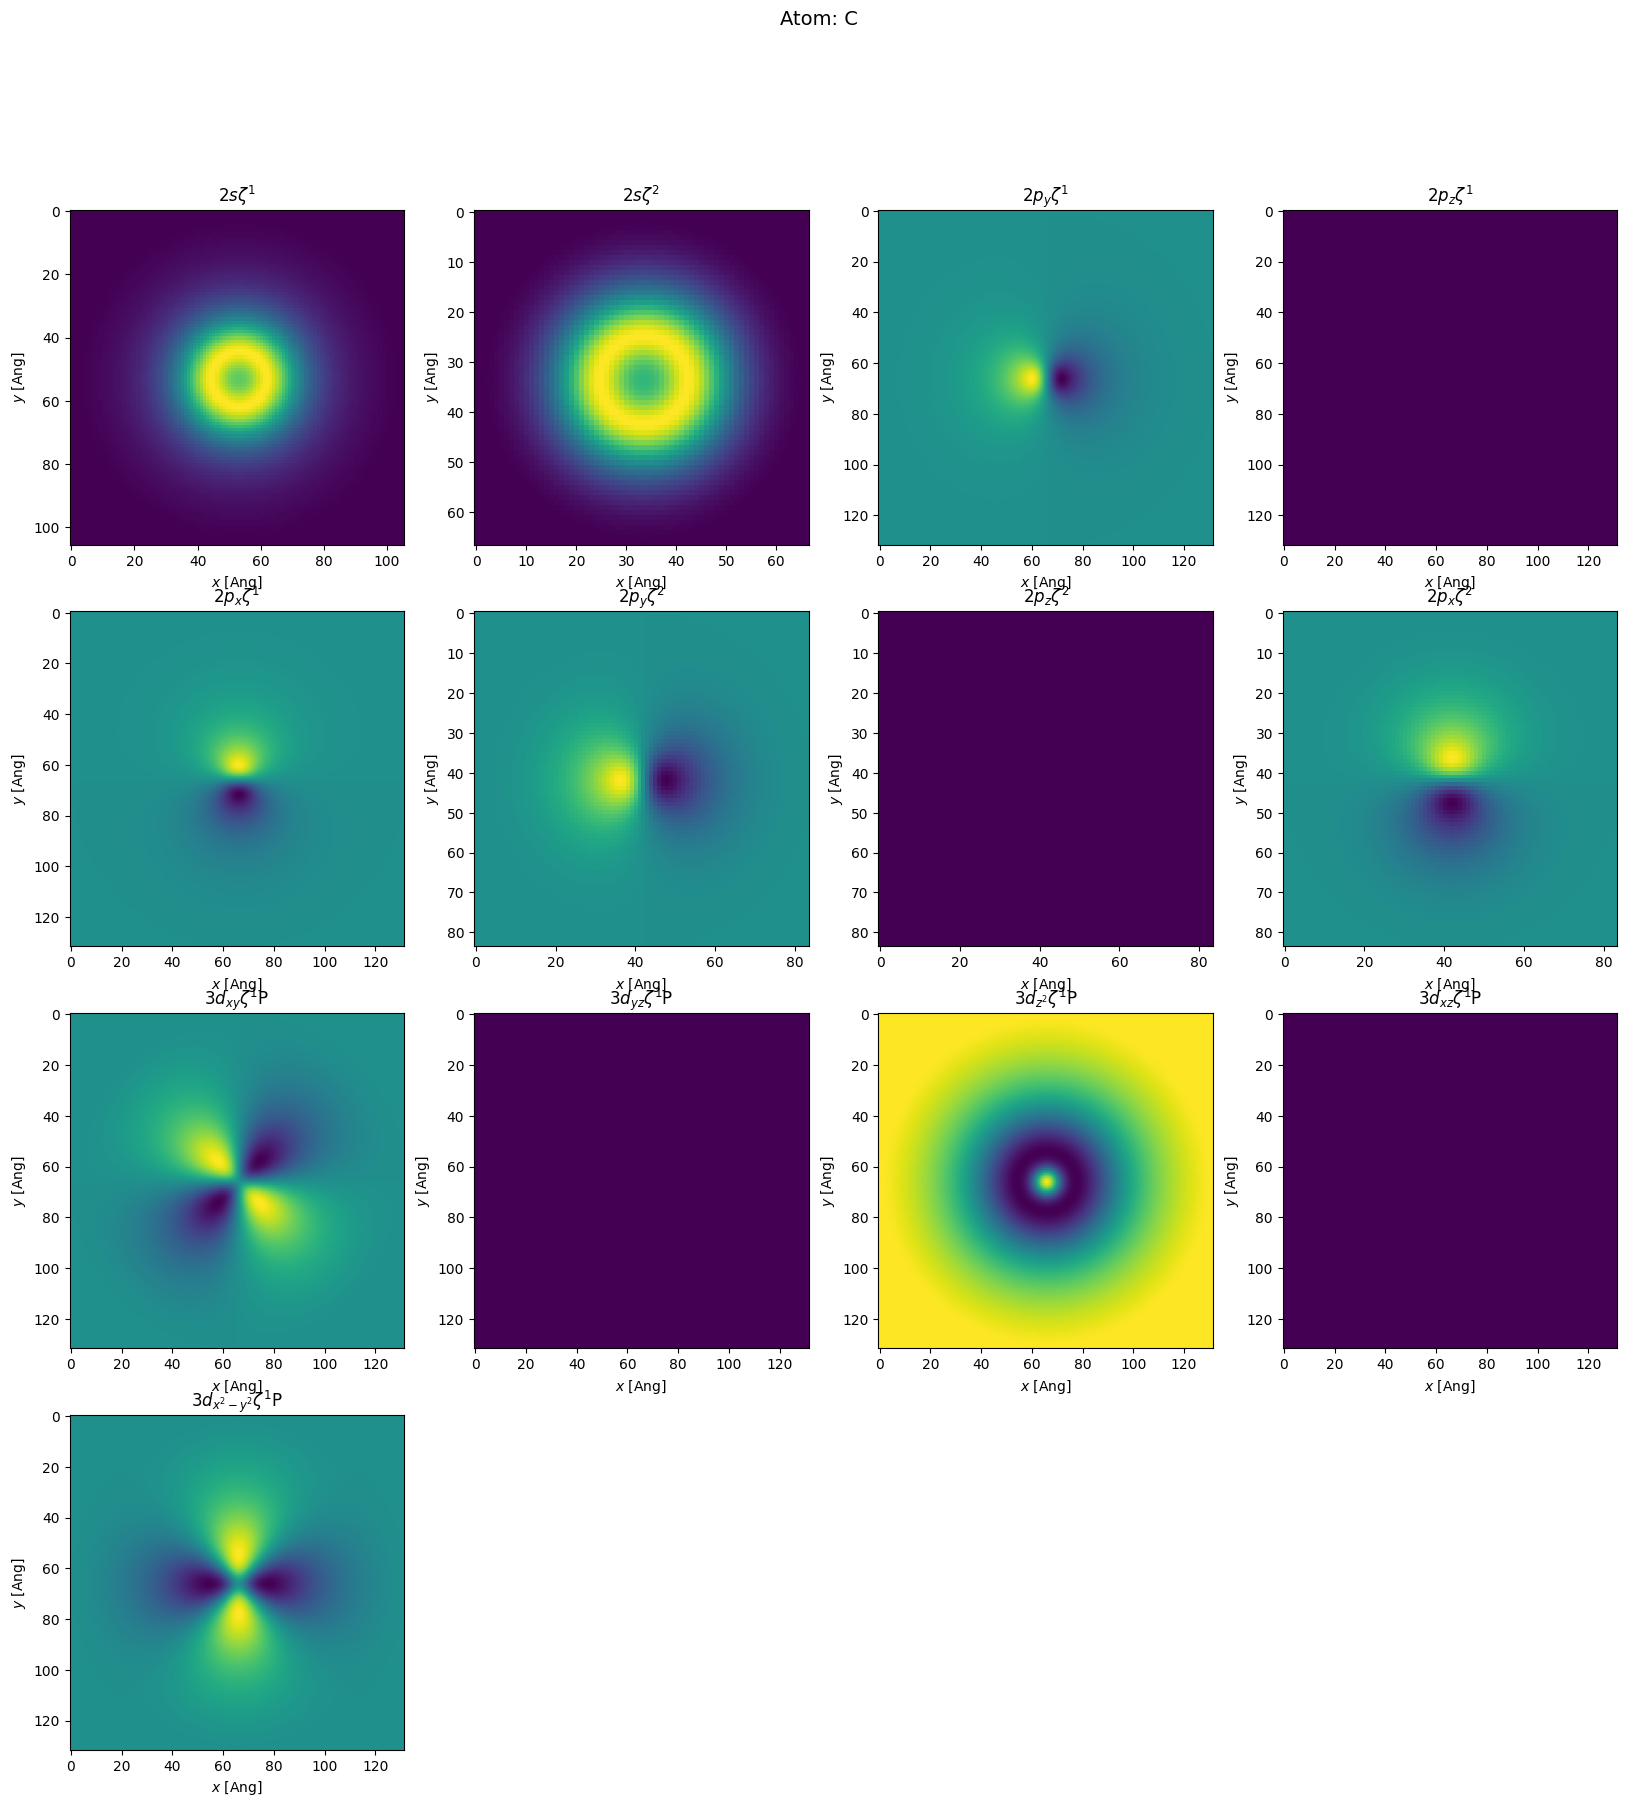

In [14]:
# FUNCTION PLOT ORBITALS
def plot_atom(atom):
    no = len(atom) # number of orbitals
    nx = no // 4
    ny = no // nx
    if nx * ny < no:
        nx += 1
    fig, axs = plt.subplots(nx, ny, figsize=(20, 5*nx))
    fig.suptitle('Atom: {}'.format(atom.symbol), fontsize=14)
    def my_plot(i, orb):
            grid = orb.toGrid(atom=atom)
            # Also write to a cube file
            grid.write('{}_{}.cube'.format(atom.symbol, orb.name()))
            c, r = i // 4, (i - 4) % 4
            if nx == 1:
                ax = axs[r]
            else:
                ax = axs[c][r]
            ax.imshow(grid.grid[:, :, grid.shape[2] // 2])
            ax.set_title(r'${}$'.format(orb.name(True)))
            ax.set_xlabel(r'$x$ [Ang]')
            ax.set_ylabel(r'$y$ [Ang]')
    i = 0
    for orb in atom:
            my_plot(i, orb)
            i += 1
    if i < nx * ny:
            # This removes the empty plots
            for j in range(i, nx * ny):
                c, r = j // 4, (j - 4) % 4
                if nx == 1:
                    ax = axs[r]
                else:
                    ax = axs[c][r]
                fig.delaxes(ax)
            plt.draw()
plot_atom(system.atoms[0])

Un cop tenim el hamiltonià, busquem obtenir els estats propis. Cada estat propi té la seva energia emmagatzemada. Podem trobar l'HOMO i el LUMO.

In [15]:
es=H.eigenstate()
es.eig

array([-17.01909909, -16.63281527, -16.62564271, -16.62383587,
       -15.89340179, -15.88639517, -15.88068881, -15.8776722 ,
       -15.8708432 , -15.19457864, -15.18868034, -15.17974138,
       -14.24497093, -14.23341232, -14.22753644, -14.21083371,
       -13.33928826, -13.32796037, -13.32324472, -13.31057918,
       -13.30088033, -12.94195192, -12.93095136, -12.91706883,
       -12.90552439, -11.9572821 , -11.95229564, -11.94467317,
       -11.94138594, -11.9285915 , -11.45923804, -11.44003554,
       -11.42514301, -10.13594004, -10.11780741, -10.09172207,
        -9.9851326 ,  -9.97550938,  -9.97176637,  -9.4931778 ,
        -9.49098625,  -9.48052183,  -9.460764  ,  -9.45491422,
        -8.14407292,  -7.88806172,  -7.87934555,  -7.87315489,
        -7.86185733,  -7.84645231,  -7.83830983,  -7.8248685 ,
        -7.81958152,  -7.79830919,  -6.80125579,  -6.78876362,
        -6.78518372,  -6.01948995,  -6.00715404,  -6.00667596,
        -5.99584281,  -5.98680315,  -5.98054121,  -5.97

Busquem l'últim orbital ocupat (HOMO) i el primer buit (LUMO).

In [16]:
idx_lumo = (es.eig > 0).nonzero()[0][0] #trick to obtain the LUMO as first positive eigenvalue
idx_homo = idx_lumo-1
print(idx_lumo)

120


In [17]:
print("HOMO E=",es.eig[idx_homo]," eV")
print("LUMO E=",es.eig[idx_lumo]," eV")

HOMO E= -0.5370867161013628  eV
LUMO E= 0.5207515730175892  eV


Creem una quadrícula i l'omplim amb la densitat de probabilitat. El resultat es pot desar en format .cube.

In [19]:
system.lattice.origin = [-10, -10, -10]
g = Grid(0.2, lattice=system.lattice)  #defines a grid matching with our system

In [20]:
es[idx_homo].wavefunction(g)
g.write('HOMO.cube')
print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))
g.fill(0) # reset the grid values to 0

info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information



Real space integrated wavefunction: 1.0000


In [21]:
es[idx_lumo].wavefunction(g)
g.write('LUMO.cube')
print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))
g.fill(0) # reset the grid values to 0

info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information



Real space integrated wavefunction: 1.0000


Deseem la densitat d'electrons

In [22]:
g2 = Grid(0.2, lattice=system.lattice)
es[idx_lumo].wavefunction(g)
g2=g*g.grid.conj()
g2.write('LUMOdens.cube')
g2.fill(0) # reset the grid values to 0

info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information



In [23]:
Gt = Grid(0.2, lattice=system.lattice)
for n in range(idx_lumo-4,idx_lumo):
    print("adding state",n)
    g.fill(0)
    es[n].wavefunction(g)
    Gt = Gt + g*g.grid.conj()
Gt.write('several_states.cube')
Gt.fill(0)


adding state 116


info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information



adding state 117


info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information



adding state 118


info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information



adding state 119


info:0: SislInfo:

wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information

